# **Problem Statement -** This project aims to develop a real-time market risk engine that dynamically computes and compares traditional and ML-based Value at Risk (VaR) models using streaming market data. It also incorporates liquidity-adjusted VaR to account for market impact and trading constraints, providing a more accurate and responsive measure of portfolio risk under varying market conditions.

## Background

Traditional Value at Risk (VaR) models assume:

- Normal return distributions  
- Static volatility  
- Instant portfolio liquidation  
- No liquidity constraints  

These assumptions often fail during:

- Market stress  
- Volatility regime shifts  
- Low-liquidity environments  

As a result, institutions may face unexpected tail losses and increased VaR breaches.

In [1]:
!pip install yfinance pandas

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15635 sha256=67477e487e09bbfd3a219fa81e6f9b6246bc2b1a4faf721488b9f2a3b3ae2858
  Stored in directory: /Users/ayushsingh/Library/Caches/pip/wheels/7e/62/f9/20d7dbb144b6f563edab8e3a7fda71d976870cd41972035cdd
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [yfinance]━━ 4/5 [yfinance]


In [5]:
import yfinance as yf
import pandas as pd

# ----------------------------
# Define date range (Last 5 Years)
# ----------------------------
start_date = "2021-01-01"
end_date = "2026-01-01"

# ----------------------------
# 5 Large-Cap NIFTY Stocks
# ----------------------------
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "INFY.NS",
    "ICICIBANK.NS"
]

# Add NIFTY 50 Index
nifty_index = "^NSEI"

# Add India VIX
india_vix = "^INDIAVIX"

tickers = stocks + [nifty_index, india_vix]

# ----------------------------
# Download Data
# ----------------------------
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    group_by="ticker",
    auto_adjust=False
)

# ----------------------------
# Keep OHLC + Volume
# ----------------------------
final_data = {}

for ticker in tickers:
    df = data[ticker][["Open", "High", "Low", "Close", "Volume"]].copy()
    df.columns = [f"{ticker}_{col}" for col in df.columns]
    final_data[ticker] = df

# Merge all into single dataframe
merged_data = pd.concat(final_data.values(), axis=1)

# Drop rows with missing values
merged_data.dropna(inplace=True)

# ----------------------------
# Save Dataset
# ----------------------------
merged_data.to_csv("nifty_market_risk_dataset.csv")

print("Dataset shape:", merged_data.shape)
print("Download complete and saved as nifty_market_risk_dataset.csv")

/opt/anaconda3/envs/myenv/lib/python3.14/site-packages/yfinance/scrapers/history.py:172: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  7 of 7 completed

Dataset shape: (1221, 35)
Download complete and saved as nifty_market_risk_dataset.csv


In [6]:
df = pd.read_csv('/Users/ayushsingh/Deep Learning/Financial Risk Management Project/Datasets/nifty_market_risk_dataset.csv')

## Dataset Description – NIFTY Market Risk Dataset

This dataset contains 5 years of daily historical market data for five large-cap NIFTY 50 stocks (RELIANCE, TCS, HDFCBANK, INFY, ICICIBANK), along with the NIFTY 50 Index and India VIX. It is designed for market risk modeling, including Traditional VaR, ML-based VaR, and Liquidity-Adjusted VaR analysis.

### What the Dataset Contains

For each stock and index:
- Open price  
- High price  
- Low price  
- Close price  
- Trading Volume  

Additionally:
- **NIFTY 50 Index (^NSEI)** – Market benchmark for systematic risk  
- **India VIX (^INDIAVIX)** – Implied volatility index representing market fear and volatility expectations  

The inclusion of trading volume allows liquidity proxy estimation, while VIX supports volatility regime detection and ML feature engineering.

---

## Data Source & Genuineness

The dataset is collected using the `yfinance` API, which retrieves historical data sourced from Yahoo Finance. Yahoo Finance aggregates official exchange data from the National Stock Exchange (NSE) and other regulated market data providers.

Key points regarding genuineness:
- Data reflects actual exchange-traded prices.
- Daily OHLC and volume values are consistent with official NSE records.
- Widely used in academic research, quantitative finance projects, and financial modeling.

While suitable for research and academic purposes, for institutional or regulatory reporting, direct NSE-authorized data feeds are recommended.

In [7]:
df.head()

,Date,RELIANCE.NS_Open,RELIANCE.NS_High,RELIANCE.NS_Low,RELIANCE.NS_Close,RELIANCE.NS_Volume,TCS.NS_Open,TCS.NS_High,TCS.NS_Low,TCS.NS_Close,...,^NSEI_Open,^NSEI_High,^NSEI_Low,^NSEI_Close,^NSEI_Volume,^INDIAVIX_Open,^INDIAVIX_High,^INDIAVIX_Low,^INDIAVIX_Close,^INDIAVIX_Volume
0,2021-01-04,920.738342,922.492004,908.231689,918.776978,24513534,2950.000000,3050.750000,2940.949951,3039.449951,...,14104.349609,14147.950195,13953.750000,14132.900391,495000,19.559999,21.030001,19.340000,20.030001,0.0
1,2021-01-05,908.693176,915.431091,902.693665,907.354858,24123091,3039.600098,3114.250000,3039.600098,3093.000000,...,14075.150391,14215.599609,14048.150391,14199.500000,492500,20.030001,21.010000,20.030001,20.459999,0.0
2,2021-01-06,907.262512,907.308655,879.226440,883.426086,46401468,3100.000000,3113.500000,3037.199951,3051.500000,...,14240.950195,14244.150391,14039.900391,14146.250000,632300,20.459999,21.629999,20.430000,21.000000,0.0
3,2021-01-07,886.310425,897.617188,879.226440,881.995422,32325918,3075.000000,3080.850098,3000.250000,3032.800049,...,14253.750000,14256.250000,14123.099609,14137.349609,559200,21.000000,21.000000,20.139999,20.620001,0.0
4,2021-01-08,885.156677,894.571289,882.433838,892.402222,27540187,3090.000000,3128.000000,3060.000000,3120.899902,...,14258.400391,14367.299805,14221.650391,14347.250000,613500,20.620001,20.850000,17.379999,20.639999,0.0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1221 entries, 0 to 1220
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 1221 non-null   str    
 1   RELIANCE.NS_Open     1221 non-null   float64
 2   RELIANCE.NS_High     1221 non-null   float64
 3   RELIANCE.NS_Low      1221 non-null   float64
 4   RELIANCE.NS_Close    1221 non-null   float64
 5   RELIANCE.NS_Volume   1221 non-null   int64  
 6   TCS.NS_Open          1221 non-null   float64
 7   TCS.NS_High          1221 non-null   float64
 8   TCS.NS_Low           1221 non-null   float64
 9   TCS.NS_Close         1221 non-null   float64
 10  TCS.NS_Volume        1221 non-null   int64  
 11  HDFCBANK.NS_Open     1221 non-null   float64
 12  HDFCBANK.NS_High     1221 non-null   float64
 13  HDFCBANK.NS_Low      1221 non-null   float64
 14  HDFCBANK.NS_Close    1221 non-null   float64
 15  HDFCBANK.NS_Volume   1221 non-null   int64  
 16 

In [9]:
df.describe()

,RELIANCE.NS_Open,RELIANCE.NS_High,RELIANCE.NS_Low,RELIANCE.NS_Close,RELIANCE.NS_Volume,TCS.NS_Open,TCS.NS_High,TCS.NS_Low,TCS.NS_Close,TCS.NS_Volume,...,^NSEI_Open,^NSEI_High,^NSEI_Low,^NSEI_Close,^NSEI_Volume,^INDIAVIX_Open,^INDIAVIX_High,^INDIAVIX_Low,^INDIAVIX_Close,^INDIAVIX_Volume
count,1221.000000,1221.000000,1221.000000,1221.000000,1.221000e+03,1221.000000,1221.000000,1221.000000,1221.000000,1.221000e+03,...,1221.000000,1221.000000,1221.000000,1221.000000,1.221000e+03,1221.000000,1221.000000,1221.000000,1221.000000,1221.0
mean,1233.924161,1245.123577,1222.475387,1233.458816,1.392981e+07,3526.712655,3557.501717,3494.703938,3525.337834,2.433832e+06,...,20091.800243,20180.518212,19979.961086,20083.484001,3.150536e+05,15.545364,16.227609,14.470532,15.539754,0.0
std,174.780469,175.478882,174.442471,175.014400,7.850217e+06,382.652772,387.863968,378.857449,382.916153,1.302441e+06,...,3573.521908,3582.352939,3572.182896,3575.390775,1.279029e+05,3.949645,4.197784,3.665208,3.953847,0.0
min,858.112793,879.157166,844.544678,850.059631,0.000000e+00,2891.000000,2915.300049,2866.600098,2888.399902,0.000000e+00,...,13758.599609,13898.250000,13596.750000,13634.599609,0.000000e+00,9.150000,9.400000,8.180000,9.150000,0.0
25%,1119.552490,1128.736328,1107.599609,1116.875732,9.049620e+06,3225.000000,3249.000000,3196.250000,3218.949951,1.621672e+06,...,17289.000000,17378.349609,17176.650391,17304.599609,2.411000e+05,12.520000,12.970000,11.620000,12.510000,0.0
50%,1210.191040,1220.413208,1199.025024,1209.599976,1.199947e+07,3434.949951,3463.000000,3408.399902,3440.149902,2.072320e+06,...,19076.849609,19175.250000,19024.599609,19122.150391,2.818000e+05,14.490000,15.230000,13.610000,14.470000,0.0
75%,1386.900024,1397.199951,1375.000000,1386.525024,1.652197e+07,3808.750000,3835.600098,3768.149902,3803.649902,2.890357e+06,...,23723.099609,23807.300781,23537.349609,23668.650391,3.556000e+05,18.020000,18.760000,16.750000,18.020000,0.0
max,1604.449951,1608.800049,1585.500000,1600.900024,9.146198e+07,4576.000000,4592.250000,4512.000000,4553.750000,1.350916e+07,...,26325.800781,26325.800781,26172.400391,26216.050781,1.103600e+06,31.980000,33.970001,28.570000,31.980000,0.0


In [10]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df.head()

,RELIANCE.NS_Open,RELIANCE.NS_High,RELIANCE.NS_Low,RELIANCE.NS_Close,RELIANCE.NS_Volume,TCS.NS_Open,TCS.NS_High,TCS.NS_Low,TCS.NS_Close,TCS.NS_Volume,...,^NSEI_Open,^NSEI_High,^NSEI_Low,^NSEI_Close,^NSEI_Volume,^INDIAVIX_Open,^INDIAVIX_High,^INDIAVIX_Low,^INDIAVIX_Close,^INDIAVIX_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,920.738342,922.492004,908.231689,918.776978,24513534,2950.000000,3050.750000,2940.949951,3039.449951,5113293,...,14104.349609,14147.950195,13953.750000,14132.900391,495000,19.559999,21.030001,19.340000,20.030001,0.0
2021-01-05,908.693176,915.431091,902.693665,907.354858,24123091,3039.600098,3114.250000,3039.600098,3093.000000,5801309,...,14075.150391,14215.599609,14048.150391,14199.500000,492500,20.030001,21.010000,20.030001,20.459999,0.0
2021-01-06,907.262512,907.308655,879.226440,883.426086,46401468,3100.000000,3113.500000,3037.199951,3051.500000,3726716,...,14240.950195,14244.150391,14039.900391,14146.250000,632300,20.459999,21.629999,20.430000,21.000000,0.0
2021-01-07,886.310425,897.617188,879.226440,881.995422,32325918,3075.000000,3080.850098,3000.250000,3032.800049,3717827,...,14253.750000,14256.250000,14123.099609,14137.349609,559200,21.000000,21.000000,20.139999,20.620001,0.0
2021-01-08,885.156677,894.571289,882.433838,892.402222,27540187,3090.000000,3128.000000,3060.000000,3120.899902,5879039,...,14258.400391,14367.299805,14221.650391,14347.250000,613500,20.620001,20.850000,17.379999,20.639999,0.0


In [12]:
# Compute Log Returns

In [11]:
import numpy as np

close_cols = [col for col in df.columns if "Close" in col]

returns = np.log(df[close_cols] / df[close_cols].shift(1))
returns.columns = [col.replace("Close", "Return") for col in close_cols]

returns.dropna(inplace=True)

returns.head()

,RELIANCE.NS_Return,TCS.NS_Return,HDFCBANK.NS_Return,INFY.NS_Return,ICICIBANK.NS_Return,^NSEI_Return,^INDIAVIX_Return
Date,,,,,,,
2021-01-05,-0.012510,0.017465,0.007528,0.004299,0.010384,0.004701,0.021241
2021-01-06,-0.026726,-0.013508,-0.004320,-0.009084,0.017437,-0.003757,0.026051
2021-01-07,-0.001621,-0.006147,-0.003032,-0.015683,-0.010296,-0.000629,-0.018261
2021-01-08,0.011730,0.028635,0.010815,0.038812,0.001754,0.014738,0.000969
2021-01-11,-0.019030,0.017643,0.013735,0.047697,0.004877,0.009538,0.080937


In [13]:
# Rolling Volatility Feature

In [14]:
volatility_20 = returns.rolling(20).std()
volatility_20.columns = [col + "_vol20" for col in returns.columns]

In [15]:
# Rolling Mean Return

In [16]:
mean_20 = returns.rolling(20).mean()
mean_20.columns = [col + "_mean20" for col in returns.columns]

In [18]:
# Rolling Skewness (Tail Behavior)

In [19]:
skew_20 = returns.rolling(20).skew()
skew_20.columns = [col + "_skew20" for col in returns.columns]

In [20]:
# Rolling Kurtosis (Fat Tails)

In [21]:
kurt_20 = returns.rolling(20).kurt()
kurt_20.columns = [col + "_kurt20" for col in returns.columns]

In [22]:
# Add Market Volatility (India VIX)

In [23]:
vix = df["^INDIAVIX_Close"]

In [24]:
# Liquidity Feature (Volume)

In [25]:
volume_cols = [col for col in df.columns if "Volume" in col]
volume = df[volume_cols]

In [26]:
features = pd.concat([
    returns,
    volatility_20,
    mean_20,
    skew_20,
    kurt_20,
    volume,
    vix
], axis=1)

features.dropna(inplace=True)

features.head()

/var/folders/xh/567fcvbs1gs5gqz64rfth0pm0000gn/T/ipykernel_30308/1344024806.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  features = pd.concat([


,RELIANCE.NS_Return,TCS.NS_Return,HDFCBANK.NS_Return,INFY.NS_Return,ICICIBANK.NS_Return,^NSEI_Return,^INDIAVIX_Return,RELIANCE.NS_Return_vol20,TCS.NS_Return_vol20,HDFCBANK.NS_Return_vol20,...,^NSEI_Return_kurt20,^INDIAVIX_Return_kurt20,RELIANCE.NS_Volume,TCS.NS_Volume,HDFCBANK.NS_Volume,INFY.NS_Volume,ICICIBANK.NS_Volume,^NSEI_Volume,^INDIAVIX_Volume,^INDIAVIX_Close
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-03,0.002515,-0.001062,0.009090,0.010486,0.008067,0.009654,0.016986,0.025684,0.015585,0.022866,...,1.638149,0.547700,30301696,2505866,20237254,8182968,27155908,869500,0.0,23.750000
2021-02-04,-0.003294,-0.003632,0.002727,-0.004134,0.009515,0.007121,-0.026884,0.025559,0.015234,0.022866,...,1.571722,0.145051,25626981,2057261,24484684,5032240,29982222,884700,0.0,23.120001
2021-02-05,-0.000286,-0.009612,0.011647,-0.005683,-0.022779,0.001918,0.012892,0.024836,0.015055,0.022800,...,1.579323,0.177845,20248046,2366135,27054716,5477481,32015570,935600,0.0,23.420000
2021-02-08,0.014296,0.017624,0.004777,0.024422,0.024845,0.012753,0.022795,0.025027,0.015338,0.022706,...,1.279905,0.411007,21183400,2526592,17447580,6921922,18230551,671200,0.0,23.959999
2021-02-09,0.002406,-0.011642,0.004103,0.001533,0.005938,-0.000430,0.012855,0.024904,0.014396,0.022685,...,1.684090,0.469687,19604141,2658751,18421366,7965949,27155615,713300,0.0,24.270000


In [27]:
#target variable (NIFTY 50) returns

In [28]:
target_returns = returns["^NSEI_Return"]

In [29]:
#Prediction target
target = target_returns.shift(-1)

In [31]:
#Rolling VaR 5 Precentile
var_5 = target_returns.rolling(252).quantile(0.05)
#252 ≈ 1 trading year window

In [32]:
ml_target = var_5.shift(-1)

In [33]:
ml_data = features.copy()

ml_data["VaR_Target"] = ml_target

ml_data.dropna(inplace=True)

ml_data.head()

,RELIANCE.NS_Return,TCS.NS_Return,HDFCBANK.NS_Return,INFY.NS_Return,ICICIBANK.NS_Return,^NSEI_Return,^INDIAVIX_Return,RELIANCE.NS_Return_vol20,TCS.NS_Return_vol20,HDFCBANK.NS_Return_vol20,...,^INDIAVIX_Return_kurt20,RELIANCE.NS_Volume,TCS.NS_Volume,HDFCBANK.NS_Volume,INFY.NS_Volume,ICICIBANK.NS_Volume,^NSEI_Volume,^INDIAVIX_Volume,^INDIAVIX_Close,VaR_Target
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-20,-0.017664,-0.022762,-0.006243,-0.023492,0.002039,-0.010164,-0.001685,0.012433,0.012698,0.012037,...,-0.513010,16494486,6176776,15197846,5533463,13567654,258100,0.0,17.790001,-0.016630
2022-01-21,0.000161,0.001815,0.008315,-0.021057,-0.007122,-0.007907,0.059996,0.012440,0.012698,0.012029,...,-0.915787,13338594,3112358,11537694,8252758,12078277,277600,0.0,18.889999,-0.017199
2022-01-24,-0.041173,-0.016345,-0.023237,-0.027766,-0.007549,-0.026927,0.189443,0.015774,0.013293,0.013274,...,6.336893,21868937,3258414,11868508,7116712,29612316,323800,0.0,22.830000,-0.017199
2022-01-25,-0.001957,-0.000385,0.000941,-0.008471,0.004000,0.007485,-0.066555,0.015538,0.013290,0.013207,...,5.579239,24510205,3330501,13594248,9137653,19513184,326500,0.0,21.360001,-0.017199
2022-01-27,-0.014922,-0.032527,-0.008843,-0.025613,-0.008770,-0.009759,-0.013670,0.015854,0.015235,0.013330,...,5.587865,20020431,5718297,28617838,11231734,23984679,395600,0.0,21.070000,-0.017199


In [36]:
display(ml_data.shape,ml_data.columns)

(969, 44)

Index(['RELIANCE.NS_Return', 'TCS.NS_Return', 'HDFCBANK.NS_Return',
       'INFY.NS_Return', 'ICICIBANK.NS_Return', '^NSEI_Return',
       '^INDIAVIX_Return', 'RELIANCE.NS_Return_vol20', 'TCS.NS_Return_vol20',
       'HDFCBANK.NS_Return_vol20', 'INFY.NS_Return_vol20',
       'ICICIBANK.NS_Return_vol20', '^NSEI_Return_vol20',
       '^INDIAVIX_Return_vol20', 'RELIANCE.NS_Return_mean20',
       'TCS.NS_Return_mean20', 'HDFCBANK.NS_Return_mean20',
       'INFY.NS_Return_mean20', 'ICICIBANK.NS_Return_mean20',
       '^NSEI_Return_mean20', '^INDIAVIX_Return_mean20',
       'RELIANCE.NS_Return_skew20', 'TCS.NS_Return_skew20',
       'HDFCBANK.NS_Return_skew20', 'INFY.NS_Return_skew20',
       'ICICIBANK.NS_Return_skew20', '^NSEI_Return_skew20',
       '^INDIAVIX_Return_skew20', 'RELIANCE.NS_Return_kurt20',
       'TCS.NS_Return_kurt20', 'HDFCBANK.NS_Return_kurt20',
       'INFY.NS_Return_kurt20', 'ICICIBANK.NS_Return_kurt20',
       '^NSEI_Return_kurt20', '^INDIAVIX_Return_kurt20', 'RELIANCE

In [37]:
ml_data = ml_data.drop(columns=["^INDIAVIX_Volume", "^NSEI_Volume"])

In [39]:
# Splitting Features

In [38]:
X = ml_data.drop(columns=["VaR_Target"])
y = ml_data["VaR_Target"]

In [40]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [41]:
# Shuffling Fainancial Data is not good for optimal results

# Model 1: Quantile Regression (ML VaR)

In [42]:
from sklearn.linear_model import QuantileRegressor

model = QuantileRegressor(quantile=0.05, alpha=0)

model.fit(X_train, y_train)

var_pred = model.predict(X_test)

In [43]:
actual_returns = returns["^NSEI_Return"].iloc[-len(var_pred):]

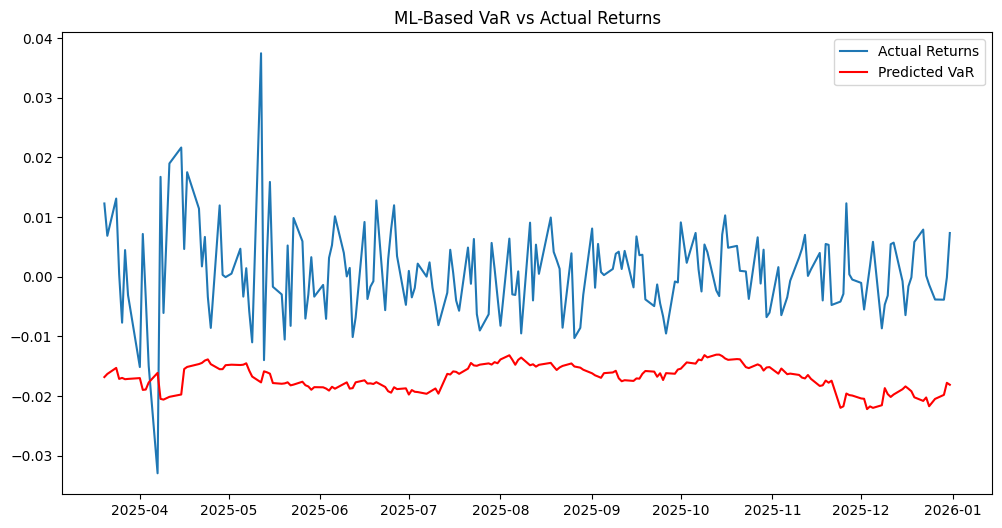

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(actual_returns.index, actual_returns, label="Actual Returns")
plt.plot(actual_returns.index, var_pred, label="Predicted VaR", color="red")

plt.legend()
plt.title("ML-Based VaR vs Actual Returns")

plt.show()

In [45]:
breaches = actual_returns < var_pred
num_breaches = breaches.sum()
total_obs = len(breaches)

breach_rate = num_breaches / total_obs

print("Total Observations:", total_obs)
print("VaR Breaches:", num_breaches)
print("Breach Rate:", breach_rate)

Total Observations: 194
VaR Breaches: 1
Breach Rate: 0.005154639175257732


The ML-based VaR model produced a breach rate significantly lower than the theoretical 5% level, indicating that the model is conservative and tends to overestimate potential losses.

# Historic VaR calculation

In [47]:
# NIFTY returns
nifty_returns = returns["^NSEI_Return"]

# Rolling Historical VaR (1 year window)
hist_var = nifty_returns.rolling(252).quantile(0.05)

hist_var = hist_var.dropna()

## Parametric VaR (Variance–Covariance Method)

The Parametric VaR approach assumes that asset returns follow a **normal distribution**.  
It estimates risk using the mean return and standard deviation of returns.

### VaR Formula

$$
VaR = \mu + Z\sigma
$$

Where:

- $\mu$ = Mean return  
- $\sigma$ = Standard deviation of returns  
- $Z$ = Z-score corresponding to the confidence level  

### For 5% VaR

$$
Z = -1.65
$$

This implies that there is a **5% probability that the portfolio loss will exceed the calculated VaR** under the normal distribution assumption.

In [48]:
import scipy.stats as stats

mu = nifty_returns.rolling(252).mean()
sigma = nifty_returns.rolling(252).std()

z = stats.norm.ppf(0.05)

param_var = mu + z * sigma

param_var = param_var.dropna()

In [49]:
comparison = pd.DataFrame({
    "Actual_Returns": nifty_returns,
    "Historical_VaR": hist_var,
    "Parametric_VaR": param_var
})

comparison = comparison.dropna()

In [50]:
hist_breach = (comparison["Actual_Returns"] < comparison["Historical_VaR"]).sum()
param_breach = (comparison["Actual_Returns"] < comparison["Parametric_VaR"]).sum()

total_obs = len(comparison)

print("Historical VaR Breaches:", hist_breach)
print("Parametric VaR Breaches:", param_breach)
print("Total Observations:", total_obs)

Historical VaR Breaches: 43
Parametric VaR Breaches: 42
Total Observations: 969


In [51]:
hist_rate = hist_breach / total_obs
param_rate = param_breach / total_obs

print("Historical VaR Breach Rate:", hist_rate)
print("Parametric VaR Breach Rate:", param_rate)

Historical VaR Breach Rate: 0.04437564499484004
Parametric VaR Breach Rate: 0.043343653250773995


In [52]:
results = pd.DataFrame({
    "Model": ["Historical VaR", "Parametric VaR", "ML VaR"],
    "Breach Rate": [hist_rate, param_rate, breach_rate]
})

results

,Model,Breach Rate
0,Historical VaR,0.044376
1,Parametric VaR,0.043344
2,ML VaR,0.005155


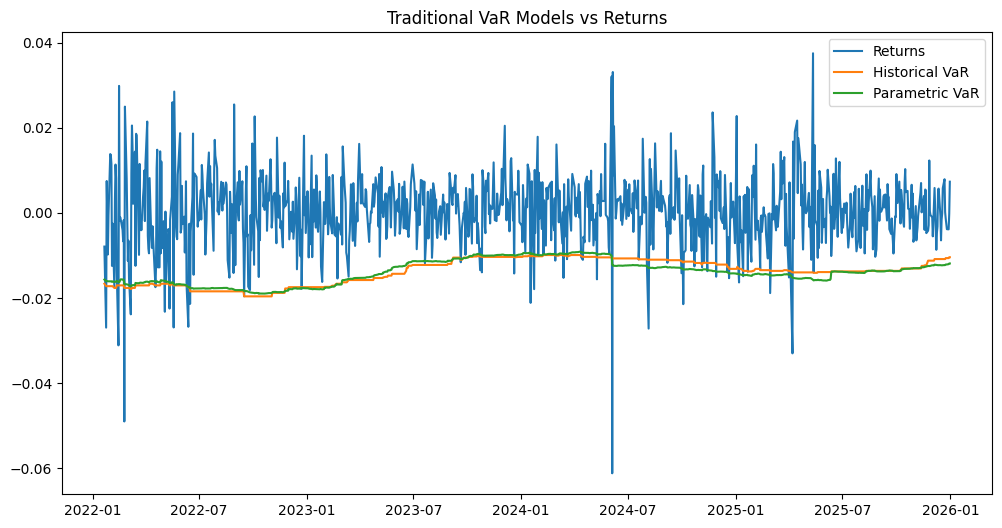

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(comparison.index, comparison["Actual_Returns"], label="Returns")
plt.plot(comparison.index, comparison["Historical_VaR"], label="Historical VaR")
plt.plot(comparison.index, comparison["Parametric_VaR"], label="Parametric VaR")

plt.legend()
plt.title("Traditional VaR Models vs Returns")

plt.show()

- ML-based VaR improves safety but sacrifices calibration
- Traditional VaR models remain strong baselines for risk estimation

In [56]:
joblib.dump({
    "model": model,
    "features": X.columns.tolist()
}, "/Users/ayushsingh/Deep Learning/Financial Risk Management Project/Models/ml_var_model.pkl")

['/Users/ayushsingh/Deep Learning/Financial Risk Management Project/Models/ml_var_model.pkl']

# To load model and metadata
saved = joblib.load("/Users/ayushsingh/Deep Learning/Financial Risk Management Project/Models/ml_var_model.pkl")

model = saved["model"]

features = saved["features"]

## Conclusion

This project developed a Market Risk modeling framework to estimate and compare Value at Risk (VaR) using both traditional statistical methods and a machine learning–based approach. A dataset consisting of five large-cap NIFTY stocks, the NIFTY 50 index, and India VIX was collected for the period 2021–2026. From this dataset, financial features such as log returns, rolling volatility, mean returns, skewness, kurtosis, trading volume, and market volatility indicators were engineered to capture market dynamics and liquidity conditions.

Three VaR models were implemented: Historical VaR, Parametric (Variance–Covariance) VaR, and an ML-based VaR model using quantile regression. The models were evaluated through backtesting using VaR breach analysis. The results showed that Historical VaR and Parametric VaR produced breach rates close to the theoretical 5% level (approximately 4.4%), indicating well-calibrated risk estimates. In contrast, the ML-based VaR model produced a significantly lower breach rate (about 0.5%), suggesting that it is more conservative and tends to overestimate potential losses.

Overall, the study demonstrates that while traditional VaR models remain reliable for estimating market risk, machine learning approaches can provide more conservative risk thresholds. The developed framework also enables real-time risk estimation by integrating live market data with the trained ML model, forming the basis for a dynamic market risk monitoring system.